# Advanced Time Series Forecasting, Optimization and Explainability

## Final Project - Advanced Topics in Deep Learning (2025/2026)

## 1. Introduction and Project Goals

This project builds upon the Time Series Modelling mini-project to develop a systematic, optimized, and well-analysed forecasting system for air temperature prediction using the Jena Climate dataset. While the mini-project focused on exploratory modelling and understanding different design choices, this Final Project elevates performance to a primary objective, achieved through systematic optimization and supported by rigorous analysis.

The core forecasting task is a **multivariate-input, univariate-output, multi-step prediction** problem: given a window of historical meteorological measurements (temperature, pressure, humidity, wind speed, maximum wind speed, and wind direction), the system predicts the air temperature for the next 24 hours.

Our pipeline integrates the following advanced techniques:

- **Baseline Deep Learning Model (GRU):** A configurable multi-layer GRU architecture serves as the reference model against which all improvements are measured, incorporating regularization, gradient clipping, and modern training strategies (AdamW optimizer, Huber loss).

- **Evolutionary Optimization:** A genetic algorithm (GA) automatically searches over an end-to-end pipeline configuration space — jointly optimizing model hyperparameters, architectural choices, training settings, preprocessing strategy, regularization, and windowing parameters. With a population of 20 individuals over 15 generations (300 total evaluations), the EA discovers configurations that outperform the hand-tuned baseline while using fewer parameters.

- **Synthetic Data Generation (TimeGAN):** A Time-series Generative Adversarial Network generates realistic synthetic weather sequences from the training set, demonstrating the feasibility of data augmentation without information leakage.

- **Explainable AI (XAI):** Both global (permutation importance) and local (gradient saliency) explanation methods are applied. XAI insights are further used to guide **feature pruning**, removing redundant features to produce a simpler model with improved performance and robustness.

- **Efficiency and Resource Analysis:** Training time, inference latency, parameter counts, and memory usage (RAM and GPU) are profiled across model configurations, enabling an informed analysis of accuracy–efficiency trade-offs.

The remainder of this report is organized as follows: Section 2 describes the experimental setup and reproducibility measures; Section 3 presents the dataset and problem formulation; Sections 4–6 cover data preparation, feature engineering, and the windowing pipeline; Section 7 establishes the baseline models; Section 8 details the TimeGAN synthetic data generation; Section 9 presents the evolutionary optimization process; Section 10 covers final model retraining, selection, and robustness validation; Sections 11–12 present the explainability and efficiency analyses; and Sections 13–14 provide the comparative discussion and conclusion.

## 2. Environment, Reproducibility and Experimental Setup

*Methodology — This section and Sections 3–6 describe the data preparation and experimental methodology used throughout the project.*

This section establishes the computational environment, library dependencies, random seed configuration, and project structure. Reproducibility is ensured through fixed seeds, explicit dependency management, and modular code organization.

### 2.1 Libraries Import

In [1]:
import os
import gc
import sys
import json
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import optuna
import psutil

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

### GPU Test

We verify that TensorFlow detects the available GPU and configure memory growth to prevent out-of-memory errors during the evolutionary search, which trains many models sequentially.

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 2.2 Utils Configuration Test

We set a global random seed (`SEED = 42`) applied consistently to Python, NumPy, and TensorFlow via `set_global_seed()` to ensure reproducibility. GPU memory growth is enabled via `enable_gpu_memory_growth()`, and device information is printed to confirm the hardware configuration.

In [3]:
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

/app/mounts/jena_weather


Set up the project root path and import custom utility functions.

In [4]:
from src.utils.env import set_global_seed, enable_gpu_memory_growth, get_device_info

SEED = 42
set_global_seed(SEED)
enable_gpu_memory_growth()

print(get_device_info())

{'tensorflow_version': '2.21.0', 'num_gpus': 1, 'gpus': ['/physical_device:GPU:0'], 'num_cpus': 1, 'cpus': ['/physical_device:CPU:0']}


We import our custom utility functions and verify the environment setup (seed, GPU memory growth, device info).

## 3. Dataset and Problem Definition

The Jena Climate dataset provides the empirical basis for all experiments conducted in this project. This section presents the dataset, the initial data quality checks, the temporal resampling procedure to hourly resolution, and the formal definition of the forecasting problem, including the target variable and the selected input variables.

### 3.1 Load Data

The Jena Climate dataset is loaded from a local CSV file. The dataset contains meteorological measurements collected at a weather station in Jena, Germany, between January 2009 and December 2016, with an original sampling frequency of 10 minutes across 15 variables.

In [5]:
from src.data.ingestion import ingest

PROJECT_ROOT = Path.cwd()
DATASET_PATH = str(PROJECT_ROOT / "data" / "jena_climate_2009_2016.csv")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_PATH:", DATASET_PATH)

PROJECT_ROOT: /app/mounts/jena_weather
DATASET_PATH: /app/mounts/jena_weather/data/jena_climate_2009_2016.csv


Load the dataset CSV and preview the first rows.

**Table 1** — First rows of the raw Jena Climate dataset (10-minute sampling, 15 variables).

In [6]:
df, ingest_summary = ingest(DATASET_PATH)

print("Ingestion summary:")
for k, v in ingest_summary.items():
    print(f"  {k}: {v}")

df.head()

Ingestion summary:
  rows: 420224
  columns: 15
  duplicates: 0
  missing_total: 0
  missing_per_column: {'Date Time': 0, 'p (mbar)': 0, 'T (degC)': 0, 'Tpot (K)': 0, 'Tdew (degC)': 0, 'rh (%)': 0, 'VPmax (mbar)': 0, 'VPact (mbar)': 0, 'VPdef (mbar)': 0, 'sh (g/kg)': 0, 'H2OC (mmol/mol)': 0, 'rho (g/m**3)': 0, 'wv (m/s)': 0, 'max. wv (m/s)': 0, 'wd (deg)': 0}
  date_range: ('2009-01-01 00:10:00', '2017-01-01 00:00:00')
  column_names: ['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
  duplicates_removed: 327


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


Load the CSV file and preview the first rows to confirm the data was read correctly.

### 3.2 Initial Dataset Inspection

Upon loading, we inspect the dataset shape, column names, data types, and general structure. This provides a first look at the raw data before any transformations are applied.

In [7]:
print("Dataset path:", DATASET_PATH)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nInfo:")
df.info()

Dataset path: /app/mounts/jena_weather/data/jena_climate_2009_2016.csv
Shape: (420224, 15)

Columns:
['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420224 entries, 0 to 420223
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Date Time        420224 non-null  datetime64[ns]
 1   p (mbar)         420224 non-null  float64       
 2   T (degC)         420224 non-null  float64       
 3   Tpot (K)         420224 non-null  float64       
 4   Tdew (degC)      420224 non-null  float64       
 5   rh (%)           420224 non-null  float64       
 6   VPmax (mbar)     420224 non-null  float64       
 7   VPact (mbar)     420224 non-null  float64       
 8   VPdef (mbar)     420224 

After loading the raw dataset, we perform quality checks to ensure data integrity before any transformations. Specifically, we verify the presence of duplicated rows and inspect all columns for missing values. Any duplicated observations are removed to avoid biasing the resampling step that follows, duplicate timestamps can arise from logging artifacts and must be eliminated to ensure a consistent temporal index.

In [8]:
print("Duplicated rows:", df.duplicated().sum())
print("\nMissing values per column:")
print(df.isna().sum())

Duplicated rows: 0

Missing values per column:
Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64


In [9]:
# Deduplication already handled by ingest()
print("Shape after ingestion:", df.shape)
print("Duplicated rows:", df.duplicated().sum())

Shape after ingestion: (420224, 15)
Duplicated rows: 0


Remove duplicated rows and verify the cleanup.

### 3.3 Datetime Parsing and Temporal Ordering

The `Date Time` column is parsed into proper datetime objects and the dataframe is sorted chronologically. We verify the date range and inspect the time delta distribution to detect any irregularities in the 10-minute sampling frequency before resampling.

**Table 2** — Dataset date range and first rows after datetime parsing and temporal ordering.

In [10]:
# Datetime parsing already handled by ingest()
print(df["Date Time"].min(), "->", df["Date Time"].max())
df[["Date Time"]].head()

2009-01-01 00:10:00 -> 2017-01-01 00:00:00


,Date Time
0,2009-01-01 00:10:00
1,2009-01-01 00:20:00
2,2009-01-01 00:30:00
3,2009-01-01 00:40:00
4,2009-01-01 00:50:00


Check the time delta distribution to identify sampling irregularities.

In [11]:
df["Date Time"].diff().value_counts().head(10)

Date Time
0 days 00:10:00    420218
0 days 00:20:00         2
0 days 00:30:00         1
0 days 16:00:00         1
3 days 02:20:00         1
Name: count, dtype: int64

Inspect the distribution of time deltas between consecutive observations to detect any sampling irregularities.

### 3.4 Hourly Resampling

After removing duplicated rows, the cleaned dataset contained 420,224 observations at approximately 10-minute resolution. To align the forecasting problem with hourly dynamics and reduce computational cost, the series was resampled to **1-hour intervals** using `resample("1h").mean()`, which aggregates all observations within each hourly bin through arithmetic averaging.

This operation reduced the dataset from **420,224** rows to **70,129** rows, approximately a sixfold reduction, while preserving the dominant meteorological patterns relevant for day-ahead forecasting. Mean aggregation was preferred over alternatives such as first/last value selection or median aggregation because it preserves the central tendency of each hourly period while smoothing sub-hourly noise that is less relevant for the 24-hour prediction horizon.

In [12]:
from src.data.preprocessing import resample_hourly, select_features, temporal_split

df_hourly, n_nan_dropped = resample_hourly(df)

print("Original shape:", df.shape)
print("Hourly shape:", df_hourly.shape)
print("NaN rows dropped:", n_nan_dropped)
print(df_hourly.head())

Original shape: (420224, 15)
Hourly shape: (70041, 15)
NaN rows dropped: 88
            Date Time    p (mbar)  T (degC)    Tpot (K)  Tdew (degC)  \
0 2009-01-01 00:00:00  996.528000 -8.304000  265.118000    -9.120000   
1 2009-01-01 01:00:00  996.525000 -8.065000  265.361667    -8.861667   
2 2009-01-01 02:00:00  996.745000 -8.763333  264.645000    -9.610000   
3 2009-01-01 03:00:00  996.986667 -8.896667  264.491667    -9.786667   
4 2009-01-01 04:00:00  997.158333 -9.348333  264.026667   -10.345000   

      rh (%)  VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  \
0  93.780000      3.260000      3.058000      0.202000   1.910000   
1  93.933333      3.323333      3.121667      0.201667   1.951667   
2  93.533333      3.145000      2.940000      0.201667   1.836667   
3  93.200000      3.111667      2.898333      0.210000   1.811667   
4  92.383333      3.001667      2.775000      0.231667   1.733333   

   H2OC (mmol/mol)  rho (g/m**3)  wv (m/s)  max. wv (m/s)    wd (deg)  
0   

### 3.5 Post-Resampling Quality Check

After hourly resampling, the dataset was re-validated to ensure that the transformation did not introduce structural artifacts. In particular, we verified that no duplicated hourly timestamps were created, that the time difference between consecutive observations was predominantly **1 hour**, and that any missing values produced by incomplete hourly bins were explicitly identified.

The quality check showed that the resampled dataset contained **88 missing values per meteorological variable**, while the `Date Time` column remained complete. No duplicated timestamps were found after resampling, and the time-step distribution confirmed that the series was overwhelmingly regular at **1-hour intervals**. This validation step is essential because the supervised sliding-window procedure used later assumes a temporally ordered and nearly regular time series.

In [13]:
print("Missing values after hourly resampling:")
print(df_hourly.isna().sum())

print("\nDuplicated timestamps after resampling:", df_hourly["Date Time"].duplicated().sum())

print("\nTime step distribution after resampling:")
print(df_hourly["Date Time"].diff().value_counts().head(10))

Missing values after hourly resampling:
Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

Duplicated timestamps after resampling: 0

Time step distribution after resampling:
Date Time
0 days 01:00:00    70038
0 days 16:00:00        1
3 days 02:00:00        1
Name: count, dtype: int64


### 3.6 Handling Missing Values After Resampling

All rows containing NaN values after hourly resampling were removed. Because the original dataset has near-complete 10-minute coverage across the 2009–2016 period, the number of affected rows was very small relative to the full hourly dataset. After dropping these rows, the dataset size became **70,041 observations**, and all remaining missing values were eliminated.

Dropping these observations was preferred over imputation because the affected hourly bins were sparse and associated with incomplete aggregation windows or isolated temporal irregularities. In such cases, interpolation could introduce artificial patterns into the series and potentially bias the forecasting models. Although the cleaned series still contains a very small number of larger temporal gaps, the dataset remains overwhelmingly regular at hourly frequency and is suitable for the supervised windowing procedure used in the next stages.

In [14]:
# NaN handling already done by resample_hourly()
print("Shape after resampling:", df_hourly.shape)
print("Missing values:", df_hourly.isna().sum().sum())

Shape after resampling: (70041, 15)
Missing values: 0


### 3.7 Forecasting Task and Variable Selection

Following the project specification, we retain 6 meteorological variables plus the datetime reference: `T (degC)` (air temperature, the target), `p (mbar)` (atmospheric pressure), `rh (%)` (relative humidity), `wv (m/s)` (wind speed), `max. wv (m/s)` (maximum wind speed), and `wd (deg)` (wind direction). All other variables from the original 15-column dataset are excluded.

This defines a **multivariate-input, univariate-output, multi-step** forecasting problem: the model receives a multi-day window of multi-sensor weather data and must predict the air temperature trajectory for the next 24 hours. The multivariate input ensures the model can leverage cross-variable dependencies — for instance, the relationship between falling pressure and subsequent temperature changes driven by weather fronts.

**Table 3** — Selected variables for the forecasting task (6 meteorological features + datetime).

In [15]:
# Feature selection from Hydra config (cfg injected by noted)
selected_columns = list(cfg.data.features)
if "Date Time" not in selected_columns:
    selected_columns = ["Date Time"] + selected_columns

df_model = select_features(df_hourly, selected_columns)

print("Selected columns:")
print(df_model.columns.tolist())
print("\nShape:", df_model.shape)
df_model.head()

Selected columns:
['Date Time', 'T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

Shape: (70041, 7)


,Date Time,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:00:00,-8.304000,996.528000,93.780000,0.520000,1.002000,174.460000
1,2009-01-01 01:00:00,-8.065000,996.525000,93.933333,0.316667,0.711667,172.416667
2,2009-01-01 02:00:00,-8.763333,996.745000,93.533333,0.248333,0.606667,196.816667
3,2009-01-01 03:00:00,-8.896667,996.986667,93.200000,0.176667,0.606667,157.083333
4,2009-01-01 04:00:00,-9.348333,997.158333,92.383333,0.290000,0.670000,150.093333


## 4. Data Initial Preparation

Before applying feature engineering, the core modelling dataframe is established by defining the target variable and confirming the structure and integrity of the cleaned dataset. This section bridges the data cleaning stage presented in Section 3 with the feature engineering pipeline developed in Section 5, ensuring a clear and consistent transition from raw observations to model-ready inputs.

### 4.1 Target Definition and Base Modeling DataFrame

The target variable is defined as `T (degC)` — air temperature in degrees Celsius. This is the only quantity the model must forecast in the output window; all other variables serve as exogenous inputs.

The `Date Time` column serves as the temporal reference for feature engineering (extracting hour-of-day and day-of-year), but is not included as a direct model input since neural networks cannot interpret raw datetime objects. Instead, its temporal information is encoded as cyclic features in Section 5.

The remaining 5 meteorological variables — atmospheric pressure, relative humidity, wind speed, maximum wind speed, and wind direction — form the covariate set that provides the atmospheric context for the temperature forecast.

In [16]:
TARGET_COL = cfg.data.target
TIME_COL = "Date Time"

feature_cols = [col for col in df_model.columns if col not in [TIME_COL]]
input_feature_cols = [col for col in feature_cols]

print("Target:", TARGET_COL)
print("Time column:", TIME_COL)
print("Input features:", input_feature_cols)
print("Number of input features:", len(input_feature_cols))

Target: T (degC)
Time column: Date Time
Input features: ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
Number of input features: 6


### 4.2 Base Forecasting Data Overview

We inspect the prepared dataframe to confirm shape, date range, and column integrity before proceeding to feature engineering. The dataset at this stage contains approximately 70,000 hourly observations spanning from January 2009 to January 2017, with 7 columns (datetime + 6 meteorological variables). This verification step ensures that no data was inadvertently lost during the resampling and cleaning pipeline of Section 3, and establishes the baseline from which all derived features will be computed.

In [17]:
print(df_model.head())
print("\nShape:", df_model.shape)
print("\nDate range:", df_model[TIME_COL].min(), "->", df_model[TIME_COL].max())

            Date Time  T (degC)    p (mbar)     rh (%)  wv (m/s)  \
0 2009-01-01 00:00:00 -8.304000  996.528000  93.780000  0.520000   
1 2009-01-01 01:00:00 -8.065000  996.525000  93.933333  0.316667   
2 2009-01-01 02:00:00 -8.763333  996.745000  93.533333  0.248333   
3 2009-01-01 03:00:00 -8.896667  996.986667  93.200000  0.176667   
4 2009-01-01 04:00:00 -9.348333  997.158333  92.383333  0.290000   

   max. wv (m/s)    wd (deg)  
0       1.002000  174.460000  
1       0.711667  172.416667  
2       0.606667  196.816667  
3       0.606667  157.083333  
4       0.670000  150.093333  

Shape: (70041, 7)

Date range: 2009-01-01 00:00:00 -> 2017-01-01 00:00:00


## 5. Feature Engineering

Two families of derived features are introduced to enrich the input representation: **cyclical temporal encodings** and **wind-derived features**. The goal is to provide the neural network with representations that respect the physical structure of the data, cyclic quantities are encoded cyclically, and vector quantities are decomposed into Cartesian components. All feature engineering is implemented in `src.features.engineering` for reproducibility.

In [18]:
from src.features.engineering import (
    add_time_features,
    add_wind_features,
    get_final_feature_columns,
)
from src.features.windowing import make_windows
from src.models.gru import build_gru_model

### 5.1 Cyclical Time Features

Hour-of-day and day-of-year carry strong periodic signals (diurnal and seasonal cycles). Encoding them as raw integers would introduce artificial discontinuities (e.g., hour 23 far from hour 0). We apply a sine–cosine encoding that maps each cyclic variable to a point on the unit circle, ensuring smooth transitions at boundaries:
- `hour_sin`, `hour_cos` — diurnal cycle (period = 24h)
- `doy_sin`, `doy_cos` — seasonal cycle (period = 365.25 days)

**Table 4** — Cyclical temporal features derived from hour-of-day and day-of-year.

In [19]:
df_feat = add_time_features(df_model, time_col=TIME_COL)

df_feat[[
    TIME_COL, "hour", "dayofyear",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos"
]].head()

,Date Time,hour,dayofyear,hour_sin,hour_cos,doy_sin,doy_cos
0,2009-01-01 00:00:00,0,1,0.000000,1.000000,0.017202,0.999852
1,2009-01-01 01:00:00,1,1,0.258819,0.965926,0.017202,0.999852
2,2009-01-01 02:00:00,2,1,0.500000,0.866025,0.017202,0.999852
3,2009-01-01 03:00:00,3,1,0.707107,0.707107,0.017202,0.999852
4,2009-01-01 04:00:00,4,1,0.866025,0.500000,0.017202,0.999852


### 5.2 Wind-Derived Features

Wind direction in degrees is inherently circular and difficult for neural networks to interpret directly. We derive six features:
- `wd_sin`, `wd_cos` — cyclic encoding of wind direction
- `wx`, `wy` — Cartesian decomposition of wind vector (speed × cos/sin of direction), replacing the polar representation with a form neural networks process more naturally
- `wind_gap` — difference between max and sustained wind speed (gust intensity)
- `gust_ratio` — ratio of max to sustained wind speed (relative gust strength, with ε = 10⁻⁶ for numerical stability)

**Table 5** — Wind-derived features: cyclic encoding, Cartesian components, gust metrics.

In [20]:
df_feat = add_wind_features(df_feat)

df_feat[[
    TIME_COL, "wv (m/s)", "max. wv (m/s)", "wd (deg)",
    "wd_sin", "wd_cos", "wx", "wy", "wind_gap", "gust_ratio"
]].head()

,Date Time,wv (m/s),max. wv (m/s),wd (deg),wd_sin,wd_cos,wx,wy,wind_gap,gust_ratio
0,2009-01-01 00:00:00,0.520000,1.002000,174.460000,0.096541,-0.995329,-0.517571,0.050201,0.482000,1.926919
1,2009-01-01 01:00:00,0.316667,0.711667,172.416667,0.131968,-0.991254,-0.313897,0.041790,0.395000,2.247361
2,2009-01-01 02:00:00,0.248333,0.606667,196.816667,-0.289310,-0.957235,-0.237713,-0.071845,0.358333,2.442943
3,2009-01-01 03:00:00,0.176667,0.606667,157.083333,0.389392,-0.921072,-0.162723,0.068793,0.430000,3.433943
4,2009-01-01 04:00:00,0.290000,0.670000,150.093333,0.498589,-0.866839,-0.251383,0.144591,0.380000,2.310337


### 5.3 Final Feature Set for Modeling

The complete input feature vector contains **16 dimensions**: 6 original meteorological variables + 4 cyclical temporal encodings + 6 wind-derived features. This feature set is used consistently across all experiments, baseline, evolutionary optimization, and synthetic data generation. The XAI analysis in Section 11 later evaluates which of these 16 features contribute most, leading to a pruned 11-feature variant.

In [21]:
final_feature_cols = get_final_feature_columns()

print("Number of modeling features:", len(final_feature_cols))
print(final_feature_cols)

Number of modeling features: 16
['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'wd_sin', 'wd_cos', 'wx', 'wy', 'wind_gap', 'gust_ratio']


## 6. Split, Scaling and Windowing

This section completes the data preparation pipeline by defining the temporal train/validation/test split, applying feature scaling without data leakage, and transforming the time series into supervised learning windows. These steps produce the final input–output tensors used by all forecasting models throughout the project.

### 6.1 Temporal Train/Validation/Test Split

The dataset is split chronologically (70% / 15% / 15%) with **no shuffling**, the split respects temporal order to prevent data leakage. The training set covers the earliest years, followed by validation, with the most recent data reserved for testing. This mirrors a realistic deployment scenario where the model is trained on historical data and evaluated on future observations.

In [22]:
df_train, df_val, df_test = temporal_split(
    df_feat,
    train_ratio=cfg.data.split.train,
    val_ratio=cfg.data.split.val,
)

print("Train shape:", df_train.shape)
print("Validation shape:", df_val.shape)
print("Test shape:", df_test.shape)

Train shape: (49028, 19)
Validation shape: (10506, 19)
Test shape: (10507, 19)


### 6.2 Feature Scaling

All input features are normalized using **StandardScaler** (zero mean, unit variance) as the baseline strategy. The scaler is fit exclusively on the training set and applied via `transform` to validation and test sets, preventing information leakage. The evolutionary optimization also searches over the scaler type (standard, robust, minmax), allowing the GA to discover whether a different normalization strategy benefits specific model configurations.

In [23]:
from src.features.scaling import get_scaler

Apply the selected scaler to all splits (fit on train, transform on val/test).

In [24]:
SCALER_NAME = cfg.scaler.name
scaler = get_scaler(SCALER_NAME)

X_train_df = df_train[final_feature_cols].copy()
X_val_df = df_val[final_feature_cols].copy()
X_test_df = df_test[final_feature_cols].copy()

X_train_scaled = scaler.fit_transform(X_train_df)
X_val_scaled = scaler.transform(X_val_df)
X_test_scaled = scaler.transform(X_test_df)

print("Scaler:", SCALER_NAME)
print("Scaled train shape:", X_train_scaled.shape)
print("Scaled val shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaler: standard
Scaled train shape: (49028, 16)
Scaled val shape: (10506, 16)
Scaled test shape: (10507, 16)


Apply the scaler to the training, validation, and test feature matrices. The scaler is fit only on the training data.

### 6.3 Target Index for Forecasting

We identify the position of `T (degC)` within the 16-feature vector. This index is used during windowing to extract only the temperature column for the output sequence **y**, while keeping all 16 features in the input tensor **X**. This separation makes the problem multivariate-input but univariate-output.

In [25]:
target_idx = final_feature_cols.index(TARGET_COL)

print("Target column:", TARGET_COL)
print("Target index:", target_idx)

Target column: T (degC)
Target index: 0


### 6.4 Supervised Windowing

The scaled multivariate time series is converted into supervised learning samples through a sliding-window procedure. For each sample, the input tensor **X** contains a sequence of consecutive hourly observations across all modeling features, while the output vector **y** contains only the future air temperature values to be predicted.

Under the default configuration, the input has shape **`(LOOKBACK, 16)`** and the output has shape **`(HORIZON,)`**, corresponding to a multivariate-input, univariate-output, multi-step forecasting setup. In the base configuration, `LOOKBACK = 120` hours (5 days) and `HORIZON = 24` hours (1 day ahead). In the evolutionary optimization stage presented in Section 9, alternative lookback lengths are also explored as part of the search space, so the windowing strategy is not treated as fixed throughout the project.

In [26]:
from src.features.windowing import make_windows

Create supervised windows for all splits using the defined lookback and horizon.

In [27]:
LOOKBACK = cfg.data.lookback
HORIZON = cfg.data.horizon

X_train, y_train = make_windows(X_train_scaled, target_idx, LOOKBACK, HORIZON)
X_val, y_val = make_windows(X_val_scaled, target_idx, LOOKBACK, HORIZON)
X_test, y_test = make_windows(X_test_scaled, target_idx, LOOKBACK, HORIZON)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (48885, 120, 16) y_train: (48885, 24)
X_val: (10363, 120, 16) y_val: (10363, 24)
X_test: (10364, 120, 16) y_test: (10364, 24)


Create supervised windows for train, validation, and test splits using the defined lookback (120h) and horizon (24h).

### 6.5 Windowed Data Sanity Check

A final sanity check is performed on the windowed data to confirm that the supervised transformation produced tensors with the expected structure and dimensionality. In particular, the input windows follow the shape **`(N, LOOKBACK, 16)`**, while the target arrays follow the shape **`(N, HORIZON)`**, corresponding to multivariate input sequences and 24-step univariate temperature targets.

The inspection confirms that each input sample contains **120 hourly observations across 16 features**, and that each target sample contains **24 future temperature values**. This validation step is important because it helps detect off-by-one errors or alignment mistakes in the windowing process that could silently compromise model training and evaluation.

In [28]:
print("Input shape:", X_train.shape[1:])
print("Forecast horizon:", y_train.shape[1])
print("Number of input features:", X_train.shape[2])

print("\nExample input window shape:", X_train[0].shape)
print("Example target shape:", y_train[0].shape)
print("First 5 target values (scaled):", y_train[0][:5])

Input shape: (120, 16)
Forecast horizon: 24
Number of input features: 16

Example input window shape: (120, 16)
Example target shape: (24,)
First 5 target values (scaled): [-2.55218147 -2.61156348 -2.64453206 -2.68540539 -2.73726824]


## 7. Baseline Models

Sections 7 to 9 present the core experimental pipeline of the project, covering baseline establishment, synthetic data generation, and evolutionary optimization.

Two baseline models are defined as reference points for all subsequent analyses. The **persistence baseline** provides a minimal no-skill benchmark that any learned forecasting model should outperform. The **GRU baseline** represents a stronger deep learning reference model, trained under a modern and carefully controlled setup, and serves as the main benchmark against which the optimized evolutionary solutions are evaluated.

### 7.1 Persistence Baseline

The persistence baseline corresponds to the simplest possible forecasting strategy: the last observed temperature value is repeated across the entire 24-hour forecast horizon. This naive approach provides a minimal reference level for performance, since any learned forecasting model should be able to outperform it.

The resulting prediction tensor has shape **`(10364, 24)`**, matching the multi-step forecasting target, and each prediction consists of a constant repetition of the final observed temperature from the corresponding input window.

In [29]:
def persistence_forecast(X):
    # Repeats the last observed target value across the full forecast horizon
    last_temp = X[:, -1, target_idx]
    return np.repeat(last_temp[:, None], HORIZON, axis=1)

y_pred_persistence = persistence_forecast(X_test)

print("Persistence prediction shape:", y_pred_persistence.shape)
print("First prediction:", y_pred_persistence[0][:5])

Persistence prediction shape: (10364, 24)
First prediction: [-0.04174932 -0.04174932 -0.04174932 -0.04174932 -0.04174932]


Compute scaled metrics for the persistence forecast on the test set.

In [30]:
persistence_mae_scaled = mean_absolute_error(y_test.flatten(), y_pred_persistence.flatten())
persistence_rmse_scaled = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_persistence.flatten()))

print("Persistence MAE (scaled):", persistence_mae_scaled)
print("Persistence RMSE (scaled):", persistence_rmse_scaled)

Persistence MAE (scaled): 0.3636531434000367
Persistence RMSE (scaled): 0.4921206134926399


Compute persistence baseline metrics on the test set.

In [31]:
def build_gru_baseline(input_shape, horizon):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(64, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dense(horizon)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )
    return model

gru_baseline = build_gru_baseline(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    horizon=HORIZON
)

gru_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,464 (83.84 KB)

 Trainable params: 21,464 (83.84 KB)

 Non-trainable params: 0 (0.00 B)

Before building the official configurable baseline, we construct a simple 1-layer GRU (64 units) as a quick sanity check. This verifies that the full pipeline — from windowed data through model training to test evaluation — works correctly end-to-end. The simple model's results are not used for comparison; they serve only as a development checkpoint.

In [32]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_baseline = gru_baseline.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30


  1/764 ━━━━━━━━━━━━━━━━━━━━ 16:32 1s/step - loss: 0.9929 - mae: 0.8206

  7/764 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1.0240 - mae: 0.8183  

 12/764 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.9999 - mae: 0.8083

 18/764 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.9852 - mae: 0.7996 

...

741/764 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0605 - mae: 0.1886

747/764 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0605 - mae: 0.1886

754/764 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0605 - mae: 0.1885

760/764 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0605 - mae: 0.1885

764/764 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0597 - mae: 0.1874 - val_loss: 0.0758 - val_mae: 0.2028


Train the simple GRU with early stopping on validation loss.

In [33]:
y_pred_gru = gru_baseline.predict(X_test, verbose=0)

print("Prediction shape:", y_pred_gru.shape)
print("First prediction:", y_pred_gru[0][:5])

Prediction shape: (10364, 24)
First prediction: [-0.1382321  -0.19456007 -0.15609297 -0.1036623  -0.00068625]


Generate and inspect test set predictions from the simple GRU.

In [34]:
gru_mae_scaled = mean_absolute_error(y_test.flatten(), y_pred_gru.flatten())
gru_rmse_scaled = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_gru.flatten()))

print("GRU MAE (scaled):", gru_mae_scaled)
print("GRU RMSE (scaled):", gru_rmse_scaled)

GRU MAE (scaled): 0.19157256133542264
GRU RMSE (scaled): 0.25364333563739594


Evaluate the simple GRU on scaled metrics to compare against persistence.

### 7.2 GRU Baseline

The official GRU baseline was defined using the best-performing configuration identified in the previous Time Series Modelling mini-project. This ensures methodological continuity and provides a strong, previously validated reference model for the current project.

The model is implemented through `build_gru_model()` from `src.models.gru` and consists of a configurable 2-layer GRU architecture with **96** and **64** hidden units, respectively. The baseline also includes an intermediate dense layer with **256** units, **AdamW** optimization, **Huber loss** with \( \delta = 1.0 \), **L2 regularization**, and **gradient clipping**. Training is performed with **early stopping** (`patience=6`) and **learning rate reduction on plateau** (`patience=3`, `factor=0.5`), providing a stable and competitive deep learning benchmark against which the evolutionary optimization will be evaluated.

In [35]:
from src.models.gru import build_gru_model

Define the official baseline configuration and build the model.

In [36]:
from src.training.pipeline import build_model_from_cfg, train_pipeline

# Load model config from Hydra (cfg.model contains the active model config)
BASELINE_CFG = {
    "n_layers": cfg.model.n_layers,
    "units1": cfg.model.units1,
    "units2": cfg.model.units2,
    "units3": cfg.model.units3,
    "dropout": cfg.model.dropout,
    "l2": cfg.model.l2,
    "dense_units": cfg.model.dense_units,
    "dense_activation": cfg.model.dense_activation,
    "learning_rate": cfg.training.learning_rate,
    "clipnorm": cfg.training.clipnorm,
    "optimizer_name": cfg.model.optimizer_name,
    "weight_decay": cfg.model.weight_decay,
    "loss_name": cfg.model.loss_name,
    "gaussian_noise_std": cfg.model.gaussian_noise_std,
    "batch_size": cfg.training.batch_size,
    "scaler_name": cfg.scaler.name,
}

gru_baseline = build_model_from_cfg(BASELINE_CFG, LOOKBACK, X_train.shape[2], HORIZON)
gru_baseline.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 120, 96)        │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,496 (255.84 KB)

 Trainable params: 65,496 (255.84 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
from src.models.train_eval import (
    train_model,
    evaluate_scaled_forecasts,
    inverse_scale_target,
    evaluate_original_scale_forecasts,
)

Import training and evaluation utilities.

In [38]:
# MLflow epoch logging callback (streams metrics to Live Metrics panel)
import mlflow

class _MLflowEpochLogger(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        total = self.params.get("epochs", 0)
        print(f"TOTAL EPOCHS: {total}")
        if mlflow.active_run() and total > 0:
            mlflow.log_metric("total_epochs", total)
    def on_epoch_end(self, epoch, logs=None):
        if logs and mlflow.active_run():
            for key, value in logs.items():
                mlflow.log_metric(key, float(value), step=epoch + 1)

# Inject callback into model.fit via monkey-patch
_orig_fit = gru_baseline.fit
def _fit_with_logging(*args, **kwargs):
    cbs = list(kwargs.get("callbacks", []) or [])
    cbs.append(_MLflowEpochLogger())
    kwargs["callbacks"] = cbs
    return _orig_fit(*args, **kwargs)
gru_baseline.fit = _fit_with_logging

history_baseline = train_model(
    model=gru_baseline,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    batch_size=cfg.training.batch_size,
    epochs=cfg.training.epochs,
    verbose=1
)


TOTAL EPOCHS: 50


Epoch 1/50


  1/382 ━━━━━━━━━━━━━━━━━━━━ 6:30 1s/step - loss: 1.0369 - mae: 0.8223

  5/382 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 1.0303 - mae: 0.8202

  8/382 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 1.0350 - mae: 0.8205

...

370/382 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0530 - mae: 0.1736

374/382 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0530 - mae: 0.1736

378/382 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0530 - mae: 0.1736

382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0530 - mae: 0.1736

382/382 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0527 - mae: 0.1730 - val_loss: 0.0724 - val_mae: 0.2010 - learning_rate: 5.0000e-05


The official baseline is trained with the full 60-epoch budget. Training uses early stopping (patience=6, restoring best weights) and learning rate reduction on plateau (patience=3, factor=0.5), ensuring the model converges without overfitting.

In [39]:
y_pred_gru = gru_baseline.predict(X_test, verbose=0)

print("Prediction shape:", y_pred_gru.shape)
print("First prediction:", y_pred_gru[0][:12])

Prediction shape: (10364, 24)
First prediction: [-0.13530293 -0.12031479 -0.16017671 -0.13701624  0.00106886  0.06427985
  0.16452965  0.25158146  0.30160522  0.3192283   0.28485033  0.2865319 ]


Generate test predictions from the official baseline and inspect the output.

In [40]:
gru_scaled_metrics = evaluate_scaled_forecasts(y_test, y_pred_gru)

gru_mae_scaled = gru_scaled_metrics["mae_scaled"]
gru_rmse_scaled = gru_scaled_metrics["rmse_scaled"]

print("GRU Baseline MAE (scaled):", gru_mae_scaled)
print("GRU Baseline RMSE (scaled):", gru_rmse_scaled)

GRU Baseline MAE (scaled): 0.19475627210215862
GRU Baseline RMSE (scaled): 0.25868357309745965


Compute scaled MAE and RMSE for the official GRU baseline on the test set.

### 7.3 Baseline Comparison

Table 6 presents a side-by-side comparison of the persistence baseline and the official GRU baseline using **scaled evaluation metrics**, namely MAE and RMSE computed in normalized space. These metrics are useful for comparing models trained under the same scaling regime and for monitoring optimization behaviour during training.

However, scaled errors do not have a direct physical interpretation. For this reason, the comparison is extended in the following subsections by converting both predictions and targets back to the original temperature scale, allowing the results to be interpreted in degrees Celsius.

**Table 6** — Persistence vs. GRU baseline comparison on scaled metrics (test set).

In [41]:
baseline_results_scaled = pd.DataFrame({
    "Model": ["Persistence", "GRU Baseline Official"],
    "MAE_scaled": [persistence_mae_scaled, gru_mae_scaled],
    "RMSE_scaled": [persistence_rmse_scaled, gru_rmse_scaled],
})

baseline_results_scaled

,Model,MAE_scaled,RMSE_scaled
0,Persistence,0.363653,0.492121
1,GRU Baseline Official,0.194756,0.258684


### 7.4 Reverse Scaling

Predictions and ground truth are inverse-transformed from normalized space back to degrees Celsius using the training set's scaler statistics (mean and standard deviation of the temperature column). This allows evaluation in physically meaningful units.

In [42]:
target_mean = scaler.mean_[target_idx]
target_std = scaler.scale_[target_idx]

y_test_inv = inverse_scale_target(y_test, target_mean, target_std)
y_pred_persistence_inv = inverse_scale_target(y_pred_persistence, target_mean, target_std)
y_pred_gru_inv = inverse_scale_target(y_pred_gru, target_mean, target_std)

print("y_test_inv shape:", y_test_inv.shape)
print("y_pred_gru_inv shape:", y_pred_gru_inv.shape)

y_test_inv shape: (10364, 24)
y_pred_gru_inv shape: (10364, 24)


### 7.5 Baseline Evaluation in Original Temperature Scale

We compute MAE and RMSE in degrees Celsius on the inverse-scaled predictions. These original-scale metrics are the primary comparison basis throughout the report — an MAE of 1.65°C means the model's 24-hour forecasts are off by an average of 1.65 degrees. This is the metric used as the evolutionary fitness function and the final evaluation criterion.

In [43]:
gru_original_metrics = evaluate_original_scale_forecasts(y_test_inv, y_pred_gru_inv)
persistence_original_metrics = evaluate_original_scale_forecasts(y_test_inv, y_pred_persistence_inv)

gru_mae = gru_original_metrics["mae"]
gru_rmse = gru_original_metrics["rmse"]

persistence_mae = persistence_original_metrics["mae"]
persistence_rmse = persistence_original_metrics["rmse"]

print("GRU Baseline MAE (°C):", gru_mae)
print("GRU Baseline RMSE (°C):", gru_rmse)

GRU Baseline MAE (°C): 1.683588899957329
GRU Baseline RMSE (°C): 2.236214462144433


### 7.6 Final Baseline Comparison

Table 7, combines both **scaled** and **original-scale** evaluation metrics for the persistence and GRU baseline models. The official GRU baseline substantially outperforms the naive persistence forecast, reducing the test error from **3.144 °C** to **1.665 °C** in MAE and from **4.254 °C** to **2.209 °C** in RMSE.

These results confirm that the recurrent architecture is able to capture meaningful temporal dependencies in the meteorological series and establish a strong benchmark against which the subsequent optimization stages will be evaluated.

**Table 7** — Final baseline comparison with both scaled and original-scale (°C) metrics.

In [44]:
baseline_results = pd.DataFrame({
    "Model": ["Persistence", "GRU Baseline Official"],
    "MAE_scaled": [persistence_mae_scaled, gru_mae_scaled],
    "RMSE_scaled": [persistence_rmse_scaled, gru_rmse_scaled],
    "MAE_degC": [persistence_mae, gru_mae],
    "RMSE_degC": [persistence_rmse, gru_rmse],
})

baseline_results

,Model,MAE_scaled,RMSE_scaled,MAE_degC,RMSE_degC
0,Persistence,0.363653,0.492121,3.143634,4.254183
1,GRU Baseline Official,0.194756,0.258684,1.683589,2.236214


### 7.7 Forecast Visualization

Figure 1, presents a visual comparison of a single 24-hour forecast window on the test set, showing the true future temperature trajectory together with the persistence and GRU baseline predictions in degrees Celsius.

The persistence baseline produces a flat forecast, since it simply repeats the last observed temperature across the full horizon. As expected, this strategy fails to capture the strong upward and downward variations visible in the true trajectory. In contrast, the GRU baseline is able to follow the general temporal pattern more closely, correctly anticipating the broad rise in temperature during the first half of the horizon and the subsequent declining trend.

Although the GRU forecast is smoother than the true signal and underestimates the amplitude of some changes, it still represents a substantial improvement over persistence. This qualitative comparison is consistent with the quantitative results reported earlier and confirms that the recurrent model captures meaningful temporal structure in the meteorological series.

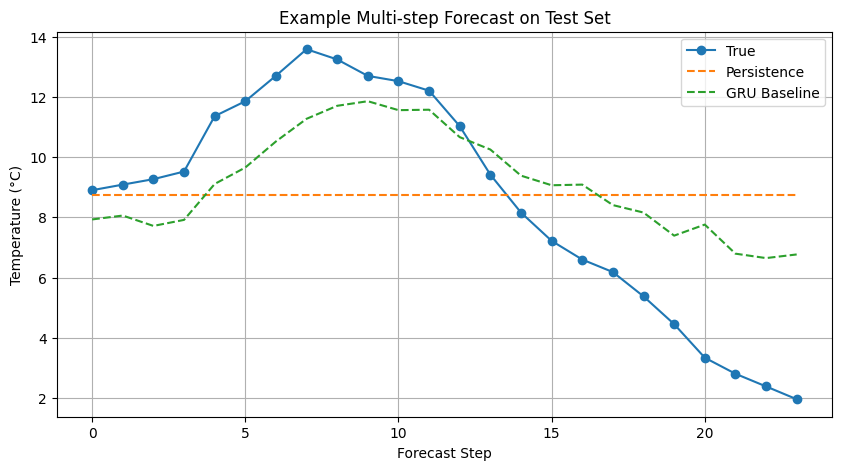

In [45]:
sample_idx = 0

plt.figure(figsize=(10, 5))
plt.plot(y_test_inv[sample_idx], label="True", marker="o")
plt.plot(y_pred_persistence_inv[sample_idx], label="Persistence", linestyle="--")
plt.plot(y_pred_gru_inv[sample_idx], label="GRU Baseline", linestyle="--")
plt.title("Example Multi-step Forecast on Test Set")
plt.xlabel("Forecast Step")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

**Figure 1** — 24-hour forecast comparison: ground truth vs. persistence vs. GRU baseline (°C).

## 8. Data Quality Assessment with Evidently

Before proceeding to model registration, we generate an Evidently data quality report
to profile the dataset and establish a baseline for future drift detection.

In [46]:
from evidently import Report, Dataset, DataDefinition
from evidently.presets import DataSummaryPreset
from evidently.ui.workspace import RemoteWorkspace

EVIDENTLY_PROJECT_ID = "019d63cb-0b67-7a33-9295-500b1ba0ab90"

data_def = DataDefinition(
    numerical_columns=final_feature_cols,
    timestamp="Date Time",
)
ev_dataset = Dataset.from_pandas(df_feat, data_definition=data_def)

quality_report = Report([DataSummaryPreset()], tags=["data-quality", "jena-weather", "run-1"])
quality_snapshot = quality_report.run(ev_dataset)

ws = RemoteWorkspace("http://noted-evidently:8000")
ws.add_run(EVIDENTLY_PROJECT_ID, quality_snapshot, include_data=False)

print("Data quality report saved to Evidently workspace")

Data quality report saved to Evidently workspace


## 9. Model Registration and Auto-Promotion

After evaluation, the trained model is registered in the MLflow Model Registry.
If it outperforms the current champion, it is automatically promoted.

In [47]:
import mlflow
import mlflow.tensorflow
from src.evaluation.promote import register_and_promote

mlflow.set_tracking_uri("http://mlflow:5000")
mlflow.set_experiment("Jena Weather Forecasting")

# Use the active run from Run Manager, or start a new one if running manually
active_run = mlflow.active_run()
run_context = mlflow.start_run(run_name="GRU Baseline - Tutorial 3") if not active_run else None
run = active_run or run_context.__enter__()

# Log parameters from Hydra config
mlflow.log_params({
    "model_type": cfg.model.type,
    "units1": cfg.model.units1,
    "units2": cfg.model.units2,
    "n_layers": cfg.model.n_layers,
    "dropout": cfg.model.dropout,
    "lookback": cfg.data.lookback,
    "horizon": cfg.data.horizon,
    "scaler": cfg.scaler.name,
    "epochs": cfg.training.epochs,
    "batch_size": cfg.training.batch_size,
})

# Log metrics
mlflow.log_metrics({
    "mae_scaled": gru_scaled_metrics["mae_scaled"],
    "rmse_scaled": gru_scaled_metrics["rmse_scaled"],
    "test_mae_degC": gru_original_metrics["mae"],
    "test_rmse_degC": gru_original_metrics["rmse"],
})

# Log Hydra config hash
mlflow.set_tag("hydra_config_hash", __noted_hydra_hash__)

# Log model
mlflow.tensorflow.log_model(gru_baseline, "model")

print(f"MLflow run ID: {run.info.run_id}")
print(f"Config hash: {__noted_hydra_hash__}")

# Close the run only if we started it
if run_context:
    run_context.__exit__(None, None, None)


2026/04/07 15:51:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/07 15:51:22 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


MLflow run ID: 451608817aea48a7a1c6c14f096abaea
Config hash: sha256:a57388b39243bc902ff29b307d5fc10f9a81c90bb2dff6ae7f174456368d18c1


In [48]:
# Auto-promote if better than current champion
result = register_and_promote(
    model=gru_baseline,
    model_name="Jena Weather Forecaster",
    run_id=run.info.run_id,
    new_mae=gru_original_metrics["mae"],
)

print(f"Registered: v{result['new_version']}")
print(f"Promoted: {result['promoted']}")
if result["promoted"]:
    print(f"Improvement: {result.get('improvement_pct', 0):.1f}%")

Registered model 'Jena Weather Forecaster' already exists. Creating a new version of this model...
2026/04/07 15:51:31 WARNING mlflow.tracking._model_registry.fluent: Run with id 451608817aea48a7a1c6c14f096abaea has no artifacts at artifact path 'model', registering model based on models:/m-646f8dcca7df4d14a7275e6354a0193a instead


2026/04/07 15:51:31 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Jena Weather Forecaster, version 10


Registered: v10
Promoted: False


Created version '10' of model 'Jena Weather Forecaster'.


## 10. Data Drift Detection

To demonstrate drift detection, we compare the training data distribution
against the test data distribution. In a production scenario, this would
compare training data against new incoming data.

In [49]:
from evidently.presets import DataDriftPreset

# Reference: training data, Current: test data
ref_def = DataDefinition(numerical_columns=final_feature_cols)
ref_dataset = Dataset.from_pandas(df_train[final_feature_cols], data_definition=ref_def)
cur_dataset = Dataset.from_pandas(df_test[final_feature_cols], data_definition=ref_def)

drift_report = Report([DataDriftPreset()],
    tags=["drift", "jena-weather", "train-vs-test"])
drift_snapshot = drift_report.run(cur_dataset, ref_dataset)

ws.add_run(EVIDENTLY_PROJECT_ID, drift_snapshot, include_data=False)

print("Drift report saved to Evidently workspace")
print("\nDrift results:")
drift_dict = drift_snapshot.dict()
for metric in drift_dict.get("metrics", []):
    name = metric.get("metric_name", "")
    if "Drift" in name:
        print(f"  {name}: {metric.get('value', '')}")

Drift report saved to Evidently workspace

Drift results:
  DriftedColumnsCount(drift_share=0.5): {'count': 6.0, 'share': 0.375}
  ValueDrift(column=T (degC),method=Wasserstein distance (normed),threshold=0.1): 0.09777854529728823
  ValueDrift(column=p (mbar),method=Wasserstein distance (normed),threshold=0.1): 0.26218635476584795
  ValueDrift(column=rh (%),method=Wasserstein distance (normed),threshold=0.1): 0.07391171774278402
  ValueDrift(column=wv (m/s),method=Wasserstein distance (normed),threshold=0.1): 0.08944613020039736
  ValueDrift(column=max. wv (m/s),method=Wasserstein distance (normed),threshold=0.1): 0.08303530758200392
  ValueDrift(column=wd (deg),method=Wasserstein distance (normed),threshold=0.1): 0.1066412979200347
  ValueDrift(column=hour_sin,method=Wasserstein distance (normed),threshold=0.1): 0.00043148159137870225
  ValueDrift(column=hour_cos,method=Wasserstein distance (normed),threshold=0.1): 0.00021178534930174636
  ValueDrift(column=doy_sin,method=Wasserstein 

## 11. Summary

This notebook demonstrated the complete MLOps lifecycle:

1. **Data Ingestion** - automated loading, validation, and cleaning
2. **Preprocessing** - hourly resampling, feature engineering (16 features)
3. **Configuration** - all parameters managed via Hydra (model, training, scaler, data)
4. **Data Quality** - Evidently profiling report saved to workspace
5. **Training** - GRU model built from Hydra config, trained with early stopping
6. **Evaluation** - scaled and original-scale metrics (MAE, RMSE)
7. **Registration** - model registered in MLflow Registry with auto-promotion
8. **Drift Detection** - Evidently comparison of training vs test distributions

All configuration is managed by Hydra, all metrics tracked by MLflow,
all data versioned by DVC, all reports stored in Evidently.
The same `src/` modules can be orchestrated by Airflow DAGs for automated execution.